# Part 2.3: Creative AI — QuickDraw Birthday Cake Sketches

## Downloading and Exploring the Dataset

In [1]:
import urllib.request

url = "https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/birthday%20cake.npy"
urllib.request.urlretrieve(url, "birthday_cake.npy")
print("Downloaded.")

Downloaded.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

data = np.load("birthday_cake.npy")
print("Shape:", data.shape)     # (num_samples, 784) - flattened 28x28 images
print("Dtype:", data.dtype)
print("Min/max pixel values:", data.min(), data.max())

Shape: (144982, 784)
Dtype: uint8
Min/max pixel values: 0 255


### Sample Sketches

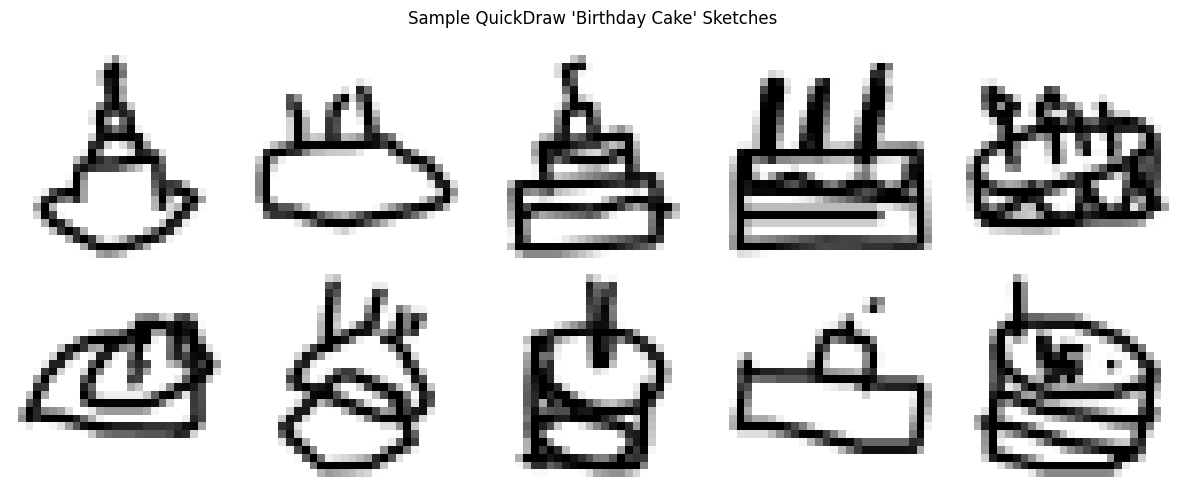

In [3]:
images = data.reshape(-1, 28, 28)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i], cmap="gray_r")  # gray_r: white background, black strokes (matches QuickDraw style)
    ax.axis("off")
plt.suptitle("Sample QuickDraw 'Birthday Cake' Sketches")
plt.tight_layout()
plt.show()

### Dataset Size and Pixel Statistics

In [4]:
print(f"Total number of birthday cake sketches: {len(images):,}")

# QuickDraw bitmaps are mostly white background (0) with sparse black strokes -
# check how "sparse" the images are, since this differs a lot from OCTMNIST's
# dense grayscale photos and will matter for GAN design.
mean_nonzero_fraction = (images > 0).mean()
print(f"Average fraction of non-zero (stroke) pixels per image: {mean_nonzero_fraction:.2%}")

Total number of birthday cake sketches: 144,982
Average fraction of non-zero (stroke) pixels per image: 33.08%


## Building the DCGAN

Same overall DCGAN architecture as Part 2.1 (OCTMNIST), reused here since both
datasets are 28×28 grayscale. QuickDraw sketches are much sparser (mostly white
background, thin black strokes) than OCTMNIST's dense grayscale scans, which is
worth watching for in the generated output quality.

In [5]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(42)

# Normalise to [-1, 1] to match Tanh generator output, same convention as Part 2.1
images_norm = (images.astype("float32") / 127.5) - 1.0
images_tensor = torch.tensor(images_norm).unsqueeze(1)  # add channel dim: (N, 1, 28, 28)

print("Tensor shape:", images_tensor.shape)
print("Min/max after normalisation:", images_tensor.min().item(), images_tensor.max().item())

# Subsample for practical training time, similar to the CICIDS approach
n_train_samples = 20000
subset_idx = torch.randperm(len(images_tensor))[:n_train_samples]
train_subset = images_tensor[subset_idx]

dataset = TensorDataset(train_subset)
batch_size = 128
train_loader_cake = DataLoader(dataset, batch_size=batch_size, shuffle=True)

print(f"Training on {n_train_samples:,} sketches (subsampled from {len(images_tensor):,} total)")

Tensor shape: torch.Size([144982, 1, 28, 28])
Min/max after normalisation: -1.0 1.0
Training on 20,000 sketches (subsampled from 144,982 total)


In [6]:
latent_dim = 100

class DCGenerator(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()
        self.model = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 128, kernel_size=7, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 1, kernel_size=4, stride=2, padding=1, bias=False),
            nn.Tanh(),
        )

    def forward(self, z):
        z = z.view(z.size(0), -1, 1, 1)
        return self.model(z)


class DCDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 1, kernel_size=7, stride=1, padding=0, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, x):
        output = self.model(x)
        return output.view(-1, 1)


cake_generator = DCGenerator(latent_dim)
cake_discriminator = DCDiscriminator()

test_noise = torch.randn(4, latent_dim)
test_fake = cake_generator(test_noise)
test_output = cake_discriminator(test_fake)
print("Generator output shape:", test_fake.shape)
print("Discriminator output shape:", test_output.shape)

Generator output shape: torch.Size([4, 1, 28, 28])
Discriminator output shape: torch.Size([4, 1])


## Training the DCGAN

In [7]:
lr = 0.0002
num_epochs = 20
beta1 = 0.5

loss_function = nn.BCELoss()
optimizer_g = torch.optim.Adam(cake_generator.parameters(), lr=lr, betas=(beta1, 0.999))
optimizer_d = torch.optim.Adam(cake_discriminator.parameters(), lr=lr, betas=(beta1, 0.999))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cake_generator.to(device)
cake_discriminator.to(device)
print("Using device:", device)

Using device: cuda


Epoch [1/20] Batch [0/157] Loss D: 1.4544 Loss G: 0.8030
Epoch [1/20] Batch [50/157] Loss D: 0.1325 Loss G: 3.6588
Epoch [1/20] Batch [100/157] Loss D: 0.7577 Loss G: 2.1042
Epoch [1/20] Batch [150/157] Loss D: 0.5624 Loss G: 2.0452


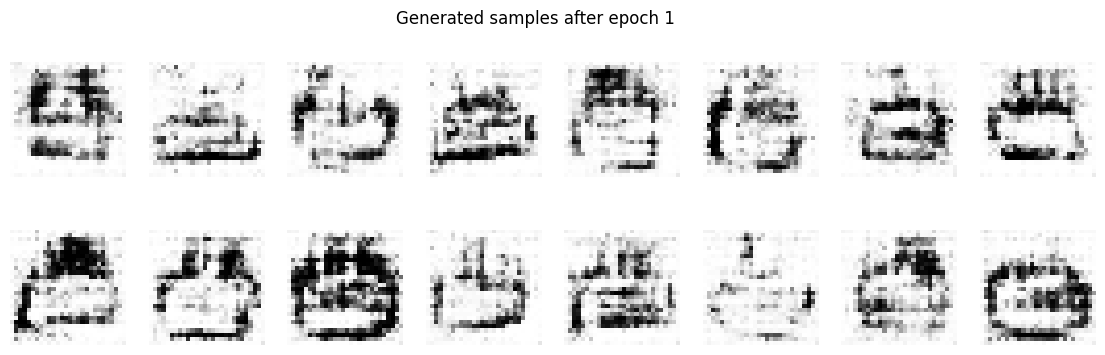

Epoch [2/20] Batch [0/157] Loss D: 0.9052 Loss G: 0.9781
Epoch [2/20] Batch [50/157] Loss D: 0.5301 Loss G: 1.5461
Epoch [2/20] Batch [100/157] Loss D: 0.4747 Loss G: 2.1991
Epoch [2/20] Batch [150/157] Loss D: 0.3509 Loss G: 2.2740


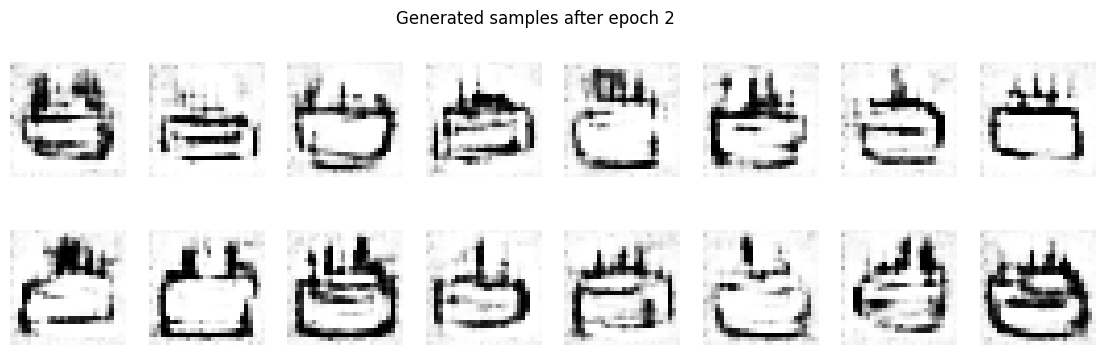

Epoch [3/20] Batch [0/157] Loss D: 0.4967 Loss G: 2.9305
Epoch [3/20] Batch [50/157] Loss D: 0.2544 Loss G: 2.3072
Epoch [3/20] Batch [100/157] Loss D: 0.2397 Loss G: 2.5050
Epoch [3/20] Batch [150/157] Loss D: 0.1779 Loss G: 2.5305


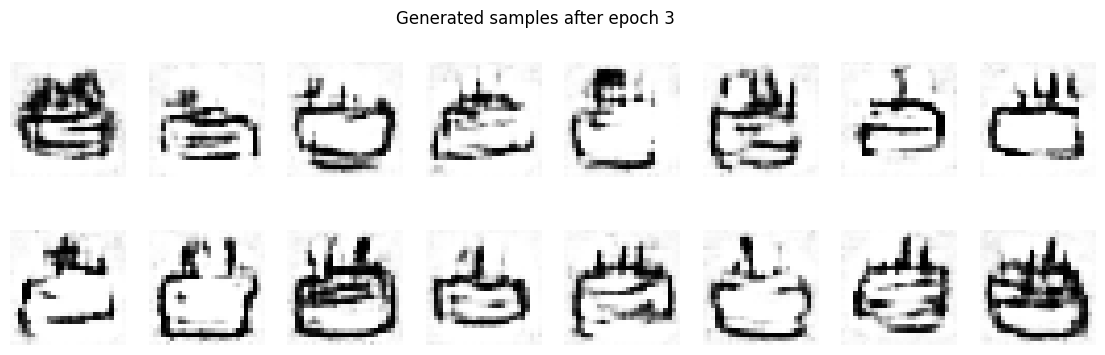

Epoch [4/20] Batch [0/157] Loss D: 0.8687 Loss G: 5.0647
Epoch [4/20] Batch [50/157] Loss D: 0.1659 Loss G: 2.7676
Epoch [4/20] Batch [100/157] Loss D: 0.1777 Loss G: 3.1661
Epoch [4/20] Batch [150/157] Loss D: 0.2070 Loss G: 2.2176


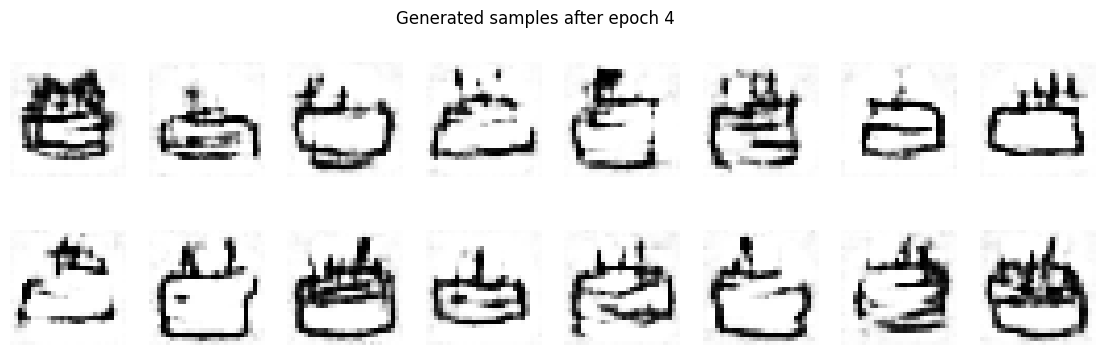

Epoch [5/20] Batch [0/157] Loss D: 0.1333 Loss G: 3.2773
Epoch [5/20] Batch [50/157] Loss D: 0.3391 Loss G: 2.0055
Epoch [5/20] Batch [100/157] Loss D: 0.1513 Loss G: 2.7592
Epoch [5/20] Batch [150/157] Loss D: 0.1591 Loss G: 2.8865


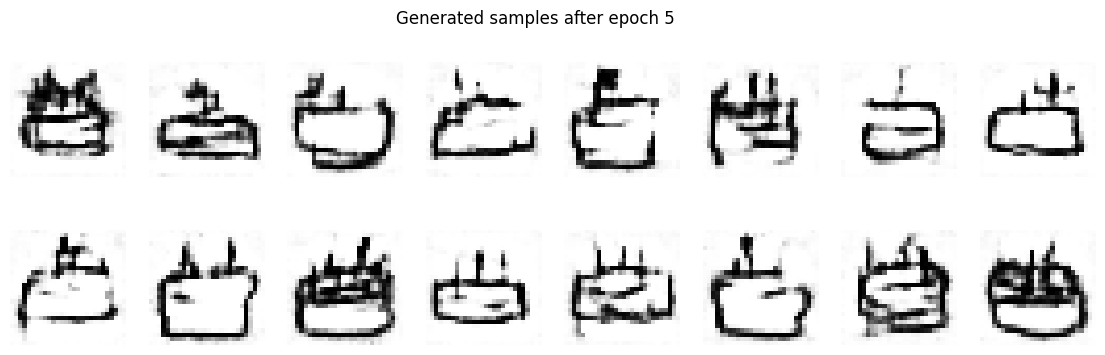

Epoch [6/20] Batch [0/157] Loss D: 0.1718 Loss G: 2.2808
Epoch [6/20] Batch [50/157] Loss D: 0.1550 Loss G: 2.6692
Epoch [6/20] Batch [100/157] Loss D: 0.1318 Loss G: 3.2214
Epoch [6/20] Batch [150/157] Loss D: 0.1615 Loss G: 2.7750


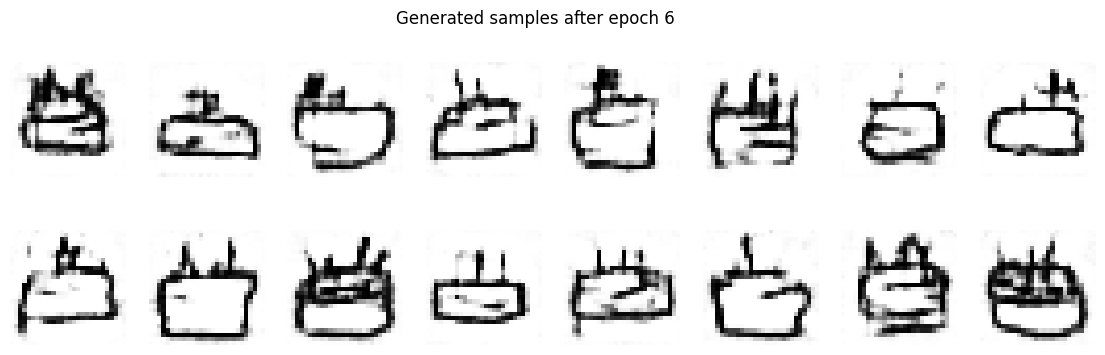

Epoch [7/20] Batch [0/157] Loss D: 0.1984 Loss G: 4.1758
Epoch [7/20] Batch [50/157] Loss D: 0.1306 Loss G: 3.0373
Epoch [7/20] Batch [100/157] Loss D: 0.4627 Loss G: 2.7131
Epoch [7/20] Batch [150/157] Loss D: 0.1234 Loss G: 3.2793


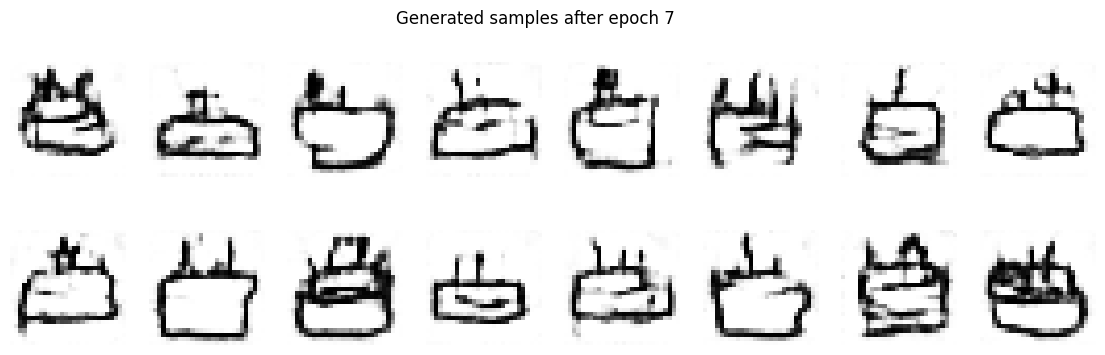

Epoch [8/20] Batch [0/157] Loss D: 0.1220 Loss G: 3.4369
Epoch [8/20] Batch [50/157] Loss D: 0.1388 Loss G: 3.1465
Epoch [8/20] Batch [100/157] Loss D: 0.1105 Loss G: 3.5213
Epoch [8/20] Batch [150/157] Loss D: 0.1022 Loss G: 3.4557


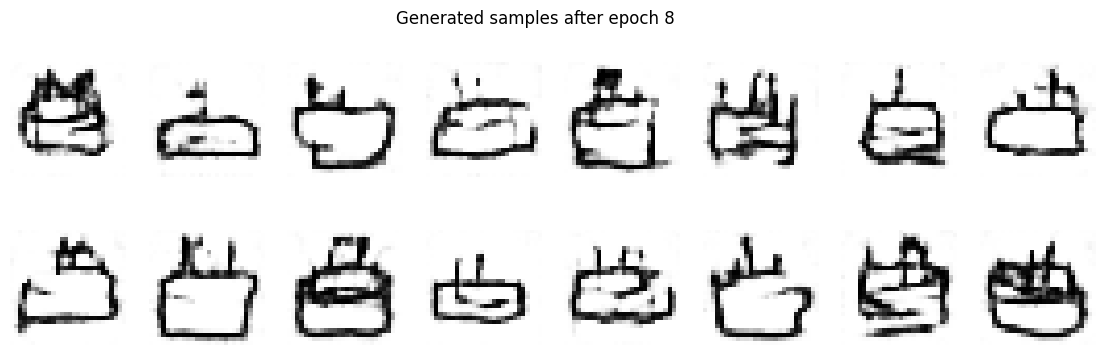

Epoch [9/20] Batch [0/157] Loss D: 0.0966 Loss G: 3.5499
Epoch [9/20] Batch [50/157] Loss D: 0.1105 Loss G: 3.5868
Epoch [9/20] Batch [100/157] Loss D: 0.1474 Loss G: 3.0166
Epoch [9/20] Batch [150/157] Loss D: 0.2265 Loss G: 2.8314


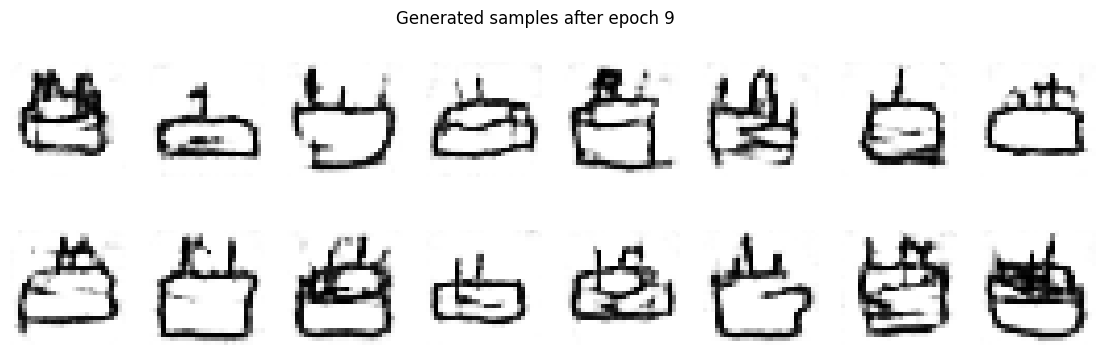

Epoch [10/20] Batch [0/157] Loss D: 0.1666 Loss G: 2.9392
Epoch [10/20] Batch [50/157] Loss D: 0.1375 Loss G: 2.8419
Epoch [10/20] Batch [100/157] Loss D: 0.1100 Loss G: 3.1643
Epoch [10/20] Batch [150/157] Loss D: 0.1299 Loss G: 3.0873


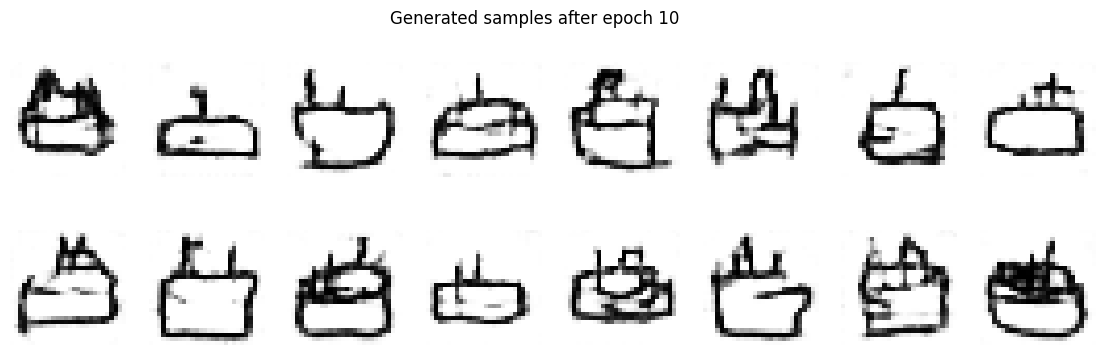

Epoch [11/20] Batch [0/157] Loss D: 0.0734 Loss G: 3.8690
Epoch [11/20] Batch [50/157] Loss D: 0.1067 Loss G: 4.1788
Epoch [11/20] Batch [100/157] Loss D: 0.3433 Loss G: 2.3438
Epoch [11/20] Batch [150/157] Loss D: 0.1830 Loss G: 3.0678


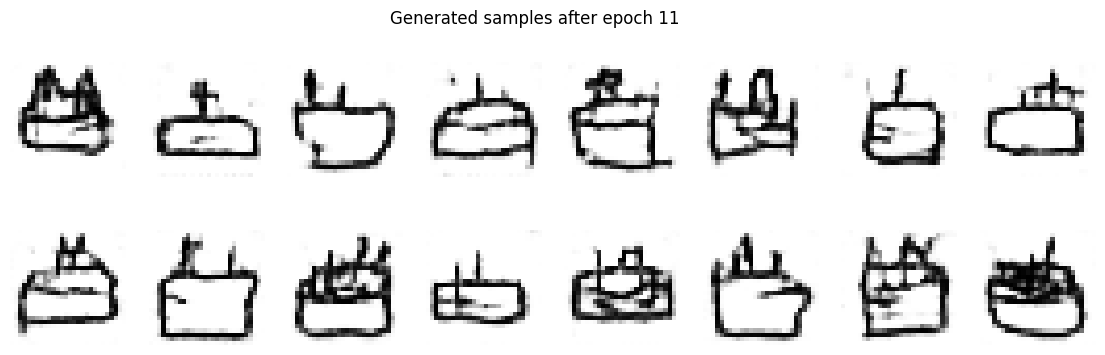

Epoch [12/20] Batch [0/157] Loss D: 0.1619 Loss G: 3.2810
Epoch [12/20] Batch [50/157] Loss D: 0.6958 Loss G: 1.3679
Epoch [12/20] Batch [100/157] Loss D: 0.1546 Loss G: 3.3595
Epoch [12/20] Batch [150/157] Loss D: 0.1700 Loss G: 3.0780


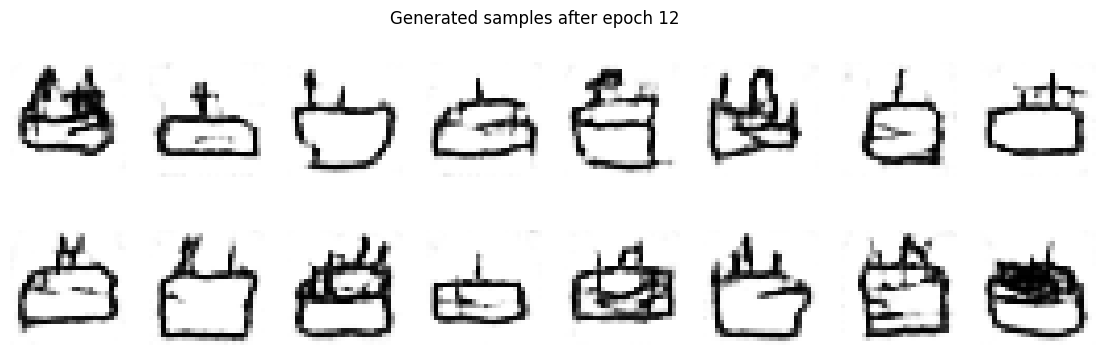

Epoch [13/20] Batch [0/157] Loss D: 0.1580 Loss G: 3.4040
Epoch [13/20] Batch [50/157] Loss D: 0.1580 Loss G: 3.5412
Epoch [13/20] Batch [100/157] Loss D: 0.1164 Loss G: 3.8780
Epoch [13/20] Batch [150/157] Loss D: 0.1214 Loss G: 3.6656


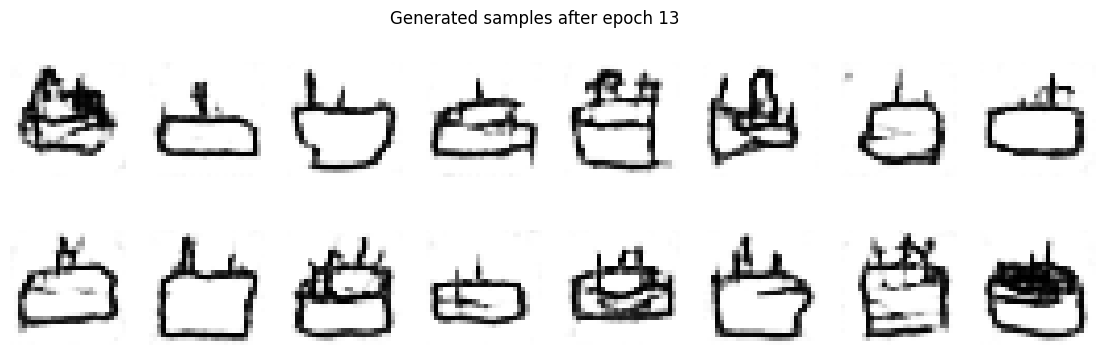

Epoch [14/20] Batch [0/157] Loss D: 0.1004 Loss G: 3.4785
Epoch [14/20] Batch [50/157] Loss D: 0.1341 Loss G: 3.1371
Epoch [14/20] Batch [100/157] Loss D: 0.1205 Loss G: 4.5135
Epoch [14/20] Batch [150/157] Loss D: 0.0999 Loss G: 4.1178


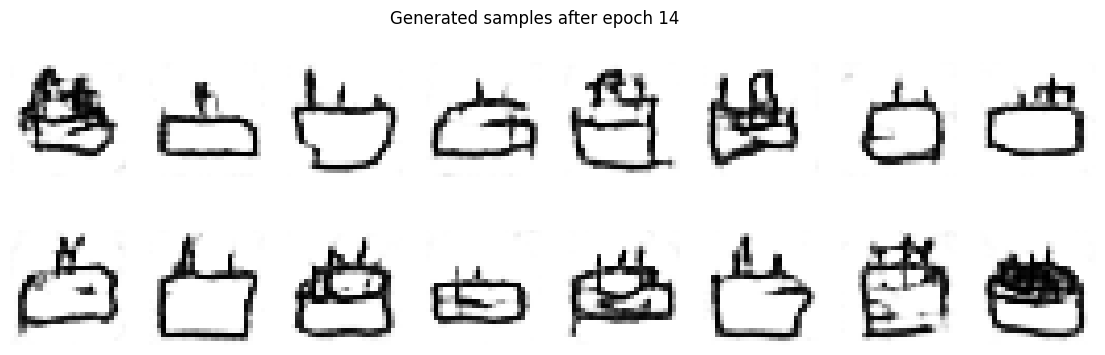

Epoch [15/20] Batch [0/157] Loss D: 0.0903 Loss G: 3.8912
Epoch [15/20] Batch [50/157] Loss D: 0.1781 Loss G: 4.6521
Epoch [15/20] Batch [100/157] Loss D: 0.1784 Loss G: 2.8649
Epoch [15/20] Batch [150/157] Loss D: 0.1120 Loss G: 4.3996


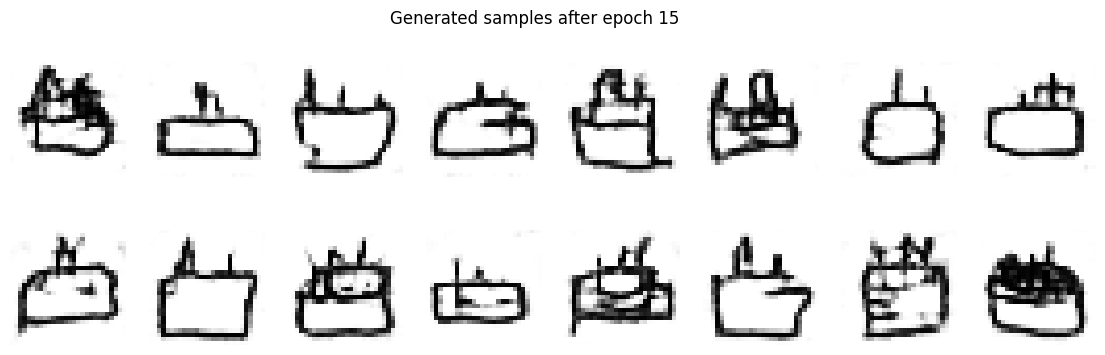

Epoch [16/20] Batch [0/157] Loss D: 0.0942 Loss G: 3.7300
Epoch [16/20] Batch [50/157] Loss D: 0.0787 Loss G: 4.2297
Epoch [16/20] Batch [100/157] Loss D: 0.1123 Loss G: 4.4660
Epoch [16/20] Batch [150/157] Loss D: 0.0970 Loss G: 3.5067


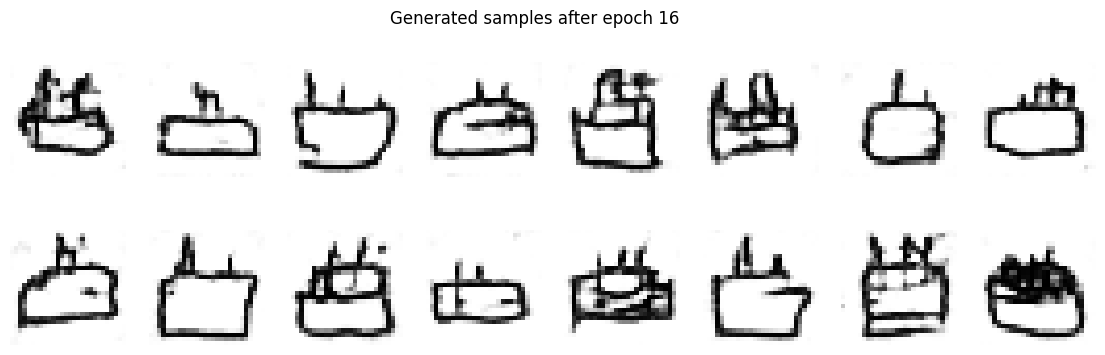

Epoch [17/20] Batch [0/157] Loss D: 3.5325 Loss G: 0.5715
Epoch [17/20] Batch [50/157] Loss D: 0.3667 Loss G: 2.9641
Epoch [17/20] Batch [100/157] Loss D: 0.3056 Loss G: 2.3774
Epoch [17/20] Batch [150/157] Loss D: 0.2571 Loss G: 2.8774


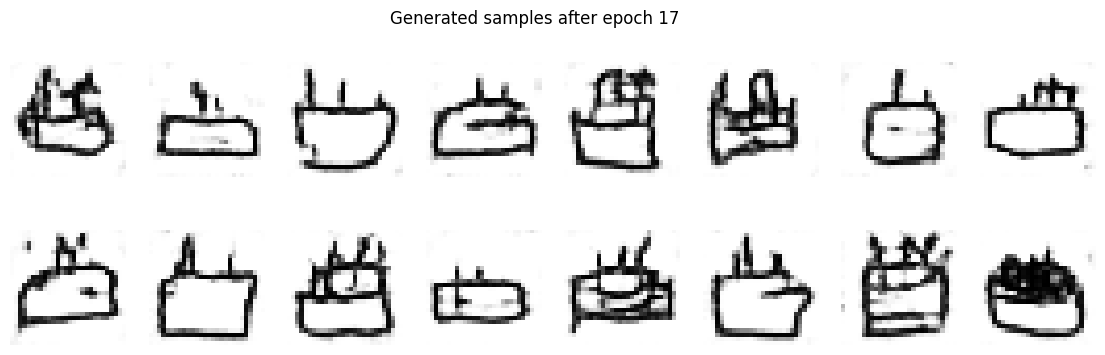

Epoch [18/20] Batch [0/157] Loss D: 0.1914 Loss G: 2.4825
Epoch [18/20] Batch [50/157] Loss D: 0.1694 Loss G: 3.1752
Epoch [18/20] Batch [100/157] Loss D: 0.1404 Loss G: 3.6161
Epoch [18/20] Batch [150/157] Loss D: 0.1052 Loss G: 3.6910


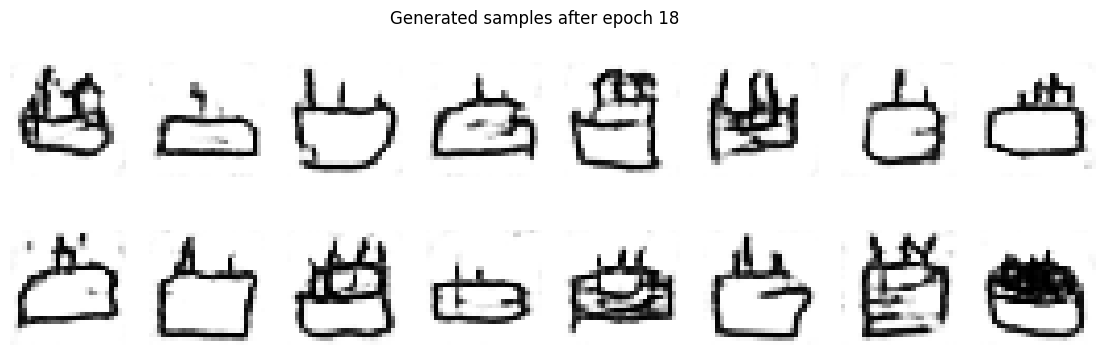

Epoch [19/20] Batch [0/157] Loss D: 0.1482 Loss G: 2.6858
Epoch [19/20] Batch [50/157] Loss D: 0.1832 Loss G: 2.5167
Epoch [19/20] Batch [100/157] Loss D: 0.1369 Loss G: 3.1663
Epoch [19/20] Batch [150/157] Loss D: 0.9060 Loss G: 1.7671


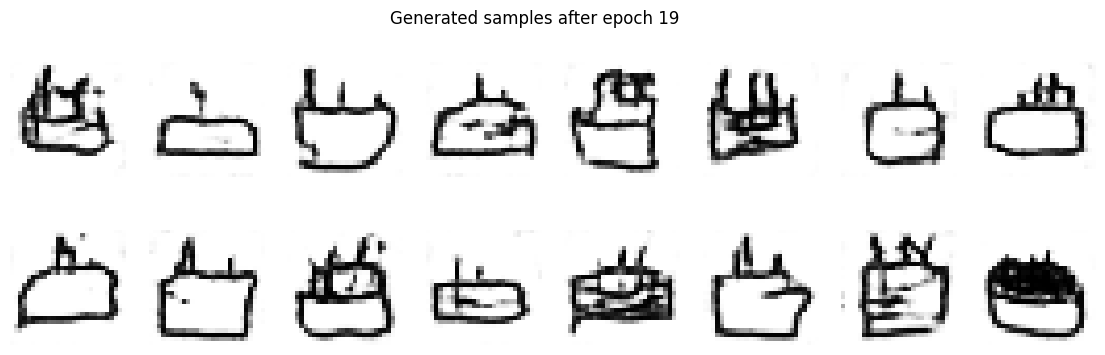

Epoch [20/20] Batch [0/157] Loss D: 0.1976 Loss G: 2.5956
Epoch [20/20] Batch [50/157] Loss D: 0.0950 Loss G: 3.8165
Epoch [20/20] Batch [100/157] Loss D: 0.1029 Loss G: 4.1519
Epoch [20/20] Batch [150/157] Loss D: 0.1285 Loss G: 3.8345


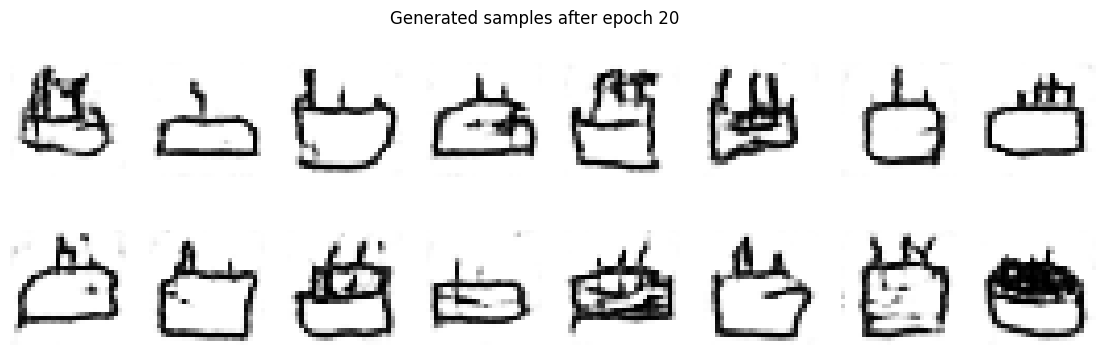

In [8]:
d_losses_cake = []
g_losses_cake = []

fixed_noise = torch.randn(16, latent_dim, device=device)

for epoch in range(num_epochs):
    for i, (real_images,) in enumerate(train_loader_cake):
        real_images = real_images.to(device)
        current_batch_size = real_images.size(0)

        real_labels = torch.ones(current_batch_size, 1, device=device)
        fake_labels = torch.zeros(current_batch_size, 1, device=device)

        # --- Train Discriminator ---
        optimizer_d.zero_grad()
        output_real = cake_discriminator(real_images)
        loss_d_real = loss_function(output_real, real_labels)

        noise = torch.randn(current_batch_size, latent_dim, device=device)
        fake_images = cake_generator(noise)
        output_fake = cake_discriminator(fake_images.detach())
        loss_d_fake = loss_function(output_fake, fake_labels)

        loss_d = loss_d_real + loss_d_fake
        loss_d.backward()
        optimizer_d.step()

        # --- Train Generator ---
        optimizer_g.zero_grad()
        output_fake_for_g = cake_discriminator(fake_images)
        loss_g = loss_function(output_fake_for_g, real_labels)
        loss_g.backward()
        optimizer_g.step()

        if i % 50 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}] Batch [{i}/{len(train_loader_cake)}] "
                  f"Loss D: {loss_d.item():.4f} Loss G: {loss_g.item():.4f}")

    d_losses_cake.append(loss_d.item())
    g_losses_cake.append(loss_g.item())

    with torch.no_grad():
        sample_imgs = cake_generator(fixed_noise).cpu()
    fig, axes = plt.subplots(2, 8, figsize=(14, 4))
    for idx, ax in enumerate(axes.flat):
        img = sample_imgs[idx].squeeze().numpy()
        img = (img * 0.5) + 0.5
        ax.imshow(img, cmap="gray_r")
        ax.axis("off")
    plt.suptitle(f"Generated samples after epoch {epoch+1}")
    plt.show()

## Plotting the Training Losses

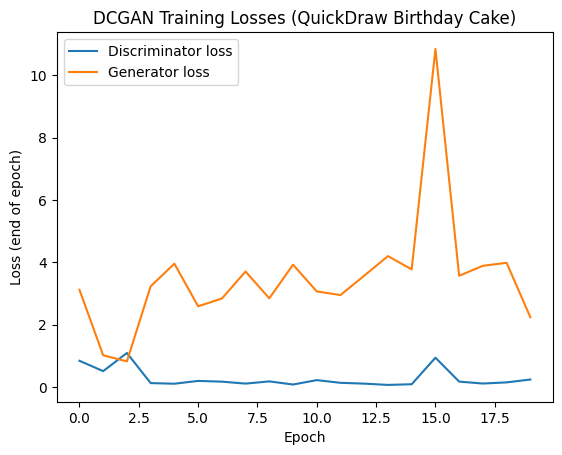

In [9]:
plt.plot(d_losses_cake, label="Discriminator loss")
plt.plot(g_losses_cake, label="Generator loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (end of epoch)")
plt.legend()
plt.title("DCGAN Training Losses (QuickDraw Birthday Cake)")
plt.show()

## Quantitative Evaluation: Fréchet Inception Distance (FID)

Same methodology as Part 2.1: images resized and channel-replicated to fit
InceptionV3's expected 299×299 RGB input. Same caveats apply regarding the
domain mismatch between InceptionV3 (trained on natural photos) and small
grayscale sketch data.

In [10]:
!pip install pytorch-fid --quiet

In [11]:
import os
from PIL import Image
np.random.seed(42)

os.makedirs("fid_real_cake", exist_ok=True)
os.makedirs("fid_fake_cake", exist_ok=True)

n_fid_samples = 1000

# Real images - sample from the full dataset, not just the training subset,
# for a broader/fairer real-data reference
real_fid_idx = np.random.choice(len(images), n_fid_samples, replace=False)
for i, idx in enumerate(real_fid_idx):
    img_np = images[idx]
    Image.fromarray(img_np.astype("uint8")).save(f"fid_real_cake/{i}.png")

# Generated images
cake_generator.eval()
with torch.no_grad():
    noise = torch.randn(n_fid_samples, latent_dim, device=device)
    fake_imgs = cake_generator(noise).cpu()

for i in range(n_fid_samples):
    img_np = fake_imgs[i].squeeze().numpy()
    img_np = ((img_np * 0.5) + 0.5) * 255
    img_np = img_np.clip(0, 255)
    Image.fromarray(img_np.astype("uint8")).save(f"fid_fake_cake/{i}.png")

print(f"Saved {n_fid_samples} real and {n_fid_samples} fake sketches for FID computation.")

Saved 1000 real and 1000 fake sketches for FID computation.


In [12]:
from pytorch_fid import fid_score

fid_value_cake = fid_score.calculate_fid_given_paths(
    ["fid_real_cake", "fid_fake_cake"],
    batch_size=50,
    device=device,
    dims=2048,
)

print(f"FID score (QuickDraw birthday cake): {fid_value_cake:.2f}")

Downloading: "https://github.com/mseitzer/pytorch-fid/releases/download/fid_weights/pt_inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/pt_inception-2015-12-05-6726825d.pth


100%|██████████| 91.2M/91.2M [00:00<00:00, 197MB/s]
100%|██████████| 20/20 [00:04<00:00,  4.51it/s]


FID score (QuickDraw birthday cake): 44.71


## Visual Comparison: Real vs Generated Sketches

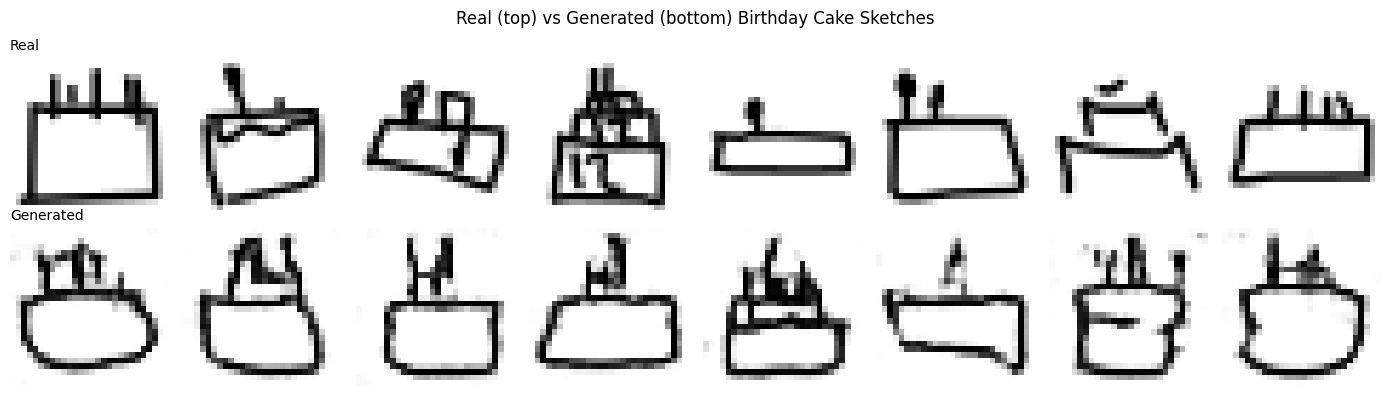

In [13]:
fig, axes = plt.subplots(2, 8, figsize=(14, 4))

# Top row: real sketches
for i in range(8):
    axes[0, i].imshow(images[real_fid_idx[i]], cmap="gray_r")
    axes[0, i].axis("off")
    if i == 0:
        axes[0, i].set_title("Real", loc="left", fontsize=10)

# Bottom row: generated sketches
for i in range(8):
    img = fake_imgs[i].squeeze().numpy()
    img = (img * 0.5) + 0.5
    axes[1, i].imshow(img, cmap="gray_r")
    axes[1, i].axis("off")
    if i == 0:
        axes[1, i].set_title("Generated", loc="left", fontsize=10)

plt.suptitle("Real (top) vs Generated (bottom) Birthday Cake Sketches")
plt.tight_layout()
plt.show()

In [15]:
real_density = (np.array([images[i] for i in real_fid_idx]) > 0).mean(axis=(1,2))

fake_imgs_rescaled = ((fake_imgs.numpy().squeeze() * 0.5) + 0.5) * 255  # back to [0, 255]
fake_density = (fake_imgs_rescaled > 20).mean(axis=(1,2))  # small threshold to ignore near-zero noise

print(f"Real sketches - mean density: {real_density.mean():.2%}, std: {real_density.std():.2%}")
print(f"Generated sketches - mean density: {fake_density.mean():.2%}, std: {fake_density.std():.2%}")

Real sketches - mean density: 33.22%, std: 6.26%
Generated sketches - mean density: 30.51%, std: 5.03%


## Quantifying Sample Diversity: Pairwise Correlation

To check whether the generator has collapsed onto a small number of repeated
outputs (mode collapse), we compute the pairwise pixel correlation across the
16 fixed-noise generated samples. High correlations between many pairs would
indicate near-duplicate outputs.

In [16]:
def pairwise_correlations(images_batch):
    flat = images_batch.reshape(images_batch.shape[0], -1)
    corr_matrix = np.corrcoef(flat)
    n = corr_matrix.shape[0]
    off_diag = corr_matrix[np.triu_indices(n, k=1)]
    return off_diag

gen_batch = sample_imgs.numpy().squeeze()
correlations = pairwise_correlations(gen_batch)

print(f"Max pairwise correlation: {correlations.max():.2f}")
print(f"Mean pairwise correlation: {correlations.mean():.2f}")

Max pairwise correlation: 0.63
Mean pairwise correlation: 0.21


## Reflecting on Synthetic Data Quality

The training loss curve initially appeared to be a warning sign, showing a persistent discriminator advantage (loss frequently in the 0.10–0.20 range against a generator loss of 2.5–9+) unlike the more balanced dynamics seen in the sine-wave, OCTMNIST, and CICIDS experiments. Closer inspection of the batch-level log reveals this was not a single destabilisation but a recurring pattern of brief spikes, each resolving within a batch or two rather than compounding into a stuck state. This is consistent with the nature of the data: QuickDraw sketches are sparse, near-binary line drawings, so the discriminator likely stumbles periodically onto an easily-detectable tell in the generator's output, producing a brief sharp win before the generator adjusts and training re-stabilises. Because each spike resolved rather than persisting, the generator's mode diversity was not compromised — confirmed independently by the pairwise correlation analysis (mean 0.21, maximum 0.63 across 16 samples), which rules out mode collapse.

The FID score for this task (44.71) is nonetheless higher — indicating a larger distributional gap — than the OCTMNIST result (37.77), despite no evidence of collapse and a close match in stroke density between real and generated sketches (33.22% ± 6.26% vs. 30.51% ± 5.03%).

Direct visual inspection of the real-vs-generated comparison grid shows that the specific weaknesses are in line quality and shape coherence rather than overall coverage or density. Generated strokes are visibly wobblier and less clean than the crisp, confident lines in real sketches, occasionally appearing smudged or doubled rather than a single stroke. Candle tops sometimes merge into a small solid blob rather than remaining distinct thin flame marks — a plausible but structurally incorrect simplification. A minority of tiles also show tier-boundary outlines that fail to fully close, leaving a small gap or overlap where a real sketch would form a continuous shape. These are comparatively subtle line-rendering flaws rather than gross structural failures, consistent with a generator that has learned the correct coarse layout of a birthday cake but has not yet learned to render crisp, topologically consistent single strokes.

Given this combination of findings — no mode collapse, reasonable density alignment, but weaker FID than the comparable OCTMNIST task — the most promising next steps would target the specific weaknesses identified rather than generic longer training. Matching the FID reference set to the actual training distribution (or, more substantively, training on a much larger fraction of the available 144,982 sketches) would remove the distributional-mismatch component of the FID gap and give a fairer comparison to OCTMNIST. Addressing the recurring training spikes directly — for example via a reduced discriminator learning rate or one-sided label smoothing — could reduce instability without needing to change model capacity. Finally, since the identified flaw is specifically stroke crispness and shape closure rather than overall coverage, a loss term more sensitive to line coherence (for example, a lightweight edge-aware or gradient-matching auxiliary term) would target the actual failure mode more directly than simply extending training time under the current BCE objective.